# RGB-D Pipeline

Using **DepthAnythingv2** metric to estimate depth

In [1]:
import torch
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForDepthEstimation
import open3d as o3d
import sys
sys.path.append("../")
from utils.imageSelector import select_equally_distributed_images

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Loading and viewing images

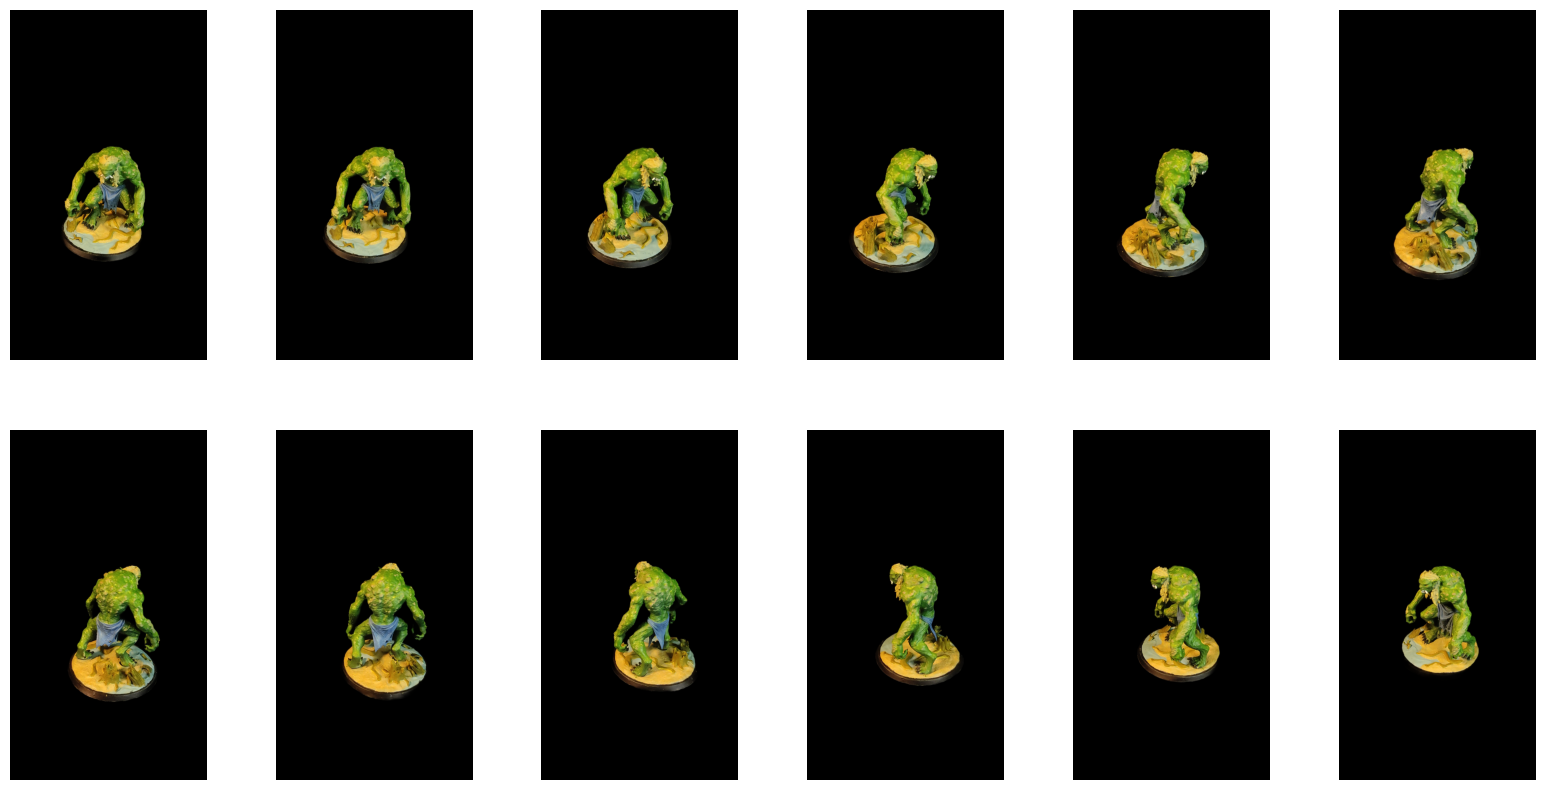

In [31]:
# Import images

input_dir = "../data/miniature"
image_paths = select_equally_distributed_images(input_dir, n = 13)[0:12]

# Load images and display them

images = [Image.open(path).convert("RGB") for path in image_paths]

f, axarr = plt.subplots(2,6, figsize=(20,10))
for i, img in enumerate(images):
    axarr[i//6, i%6].imshow(img)
    axarr[i//6, i%6].axis('off')
plt.show()


## Generating the Depth Images

In [32]:
# Loading the model

model_path = "depth-anything/Depth-Anything-V2-Metric-Indoor-Large-hf"
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForDepthEstimation.from_pretrained(model_path).eval()

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

In [33]:
# Generate depth maps

depth_maps = []
for image in images:
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        predicted_depth = outputs.predicted_depth.squeeze().cpu().numpy()
    
    # Resize to match input resolution
    predicted_depth_resized = cv2.resize(predicted_depth, (image.width, image.height))
    
    depth_maps.append(predicted_depth_resized)

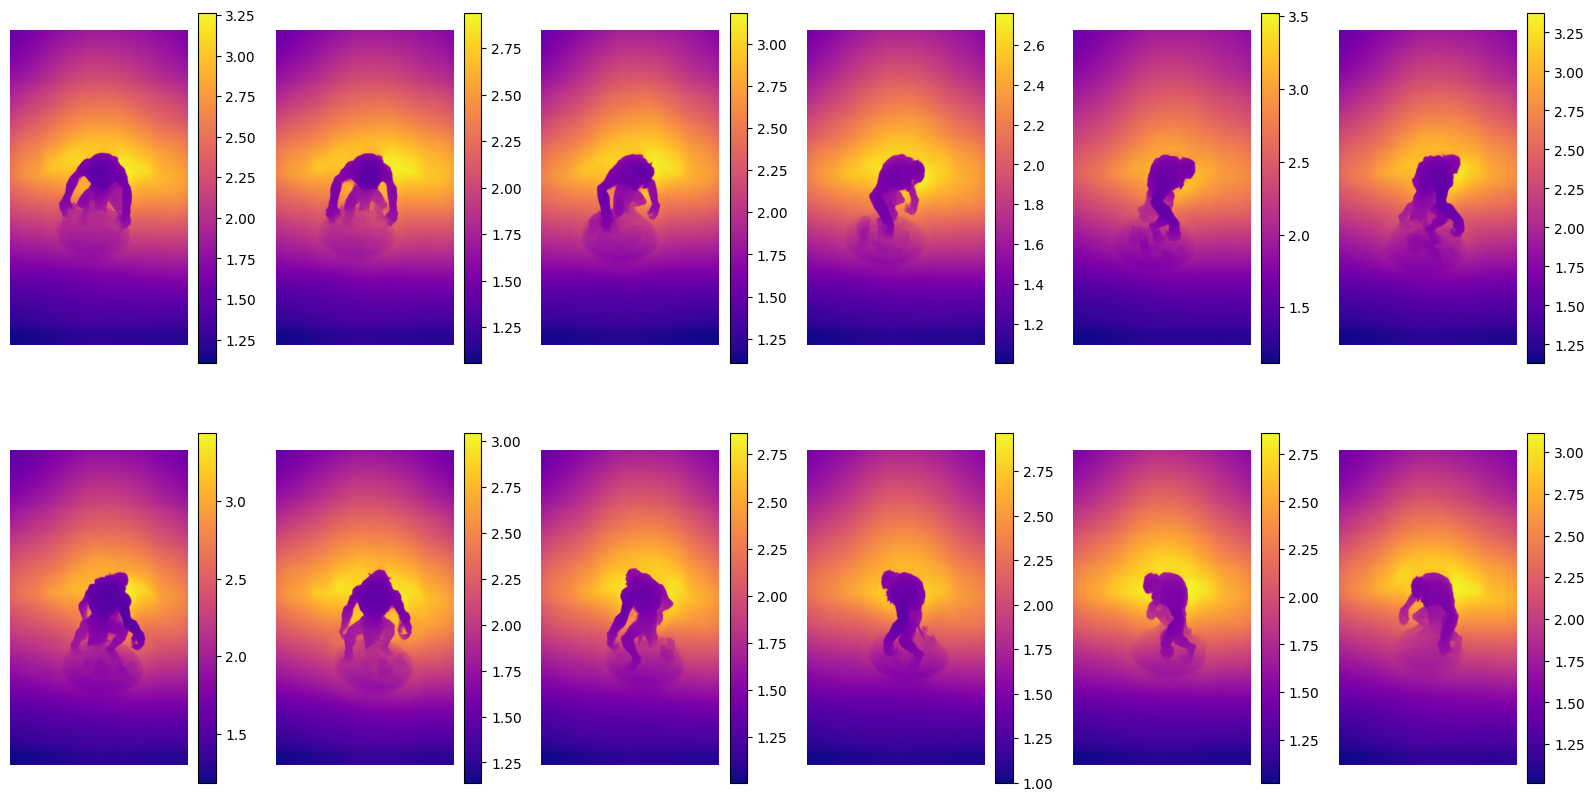

In [34]:
# Visualize the depth maps

f, axarr = plt.subplots(2,6, figsize=(20,10))
for i, img in enumerate(depth_maps):
    im = axarr[i//6, i%6].imshow(img, cmap='plasma')
    axarr[i//6, i%6].axis('off')
    f.colorbar(im, ax=axarr[i//6, i%6])
plt.show()

## Merge the images to produce RGBD

In [35]:
# Merge the RGB and depth information to create a RGBD image

rgbd_images = []
for img, depth in zip(images, depth_maps):
    rgbd = np.dstack((np.array(img), depth))
    rgbd_images.append(rgbd)

In [36]:
fx = 470.4  # focal length x (pixels)
fy = 470.4  # focal length y (pixels)

cx, cy = images[0].width / 2, images[0].height / 2  # principal point (pixels)

## Extract SIFT Features

Keypoints per image: [2216, 2001, 1778, 1656, 1697, 1802, 2348, 1950, 1753, 1573, 1719, 1639]


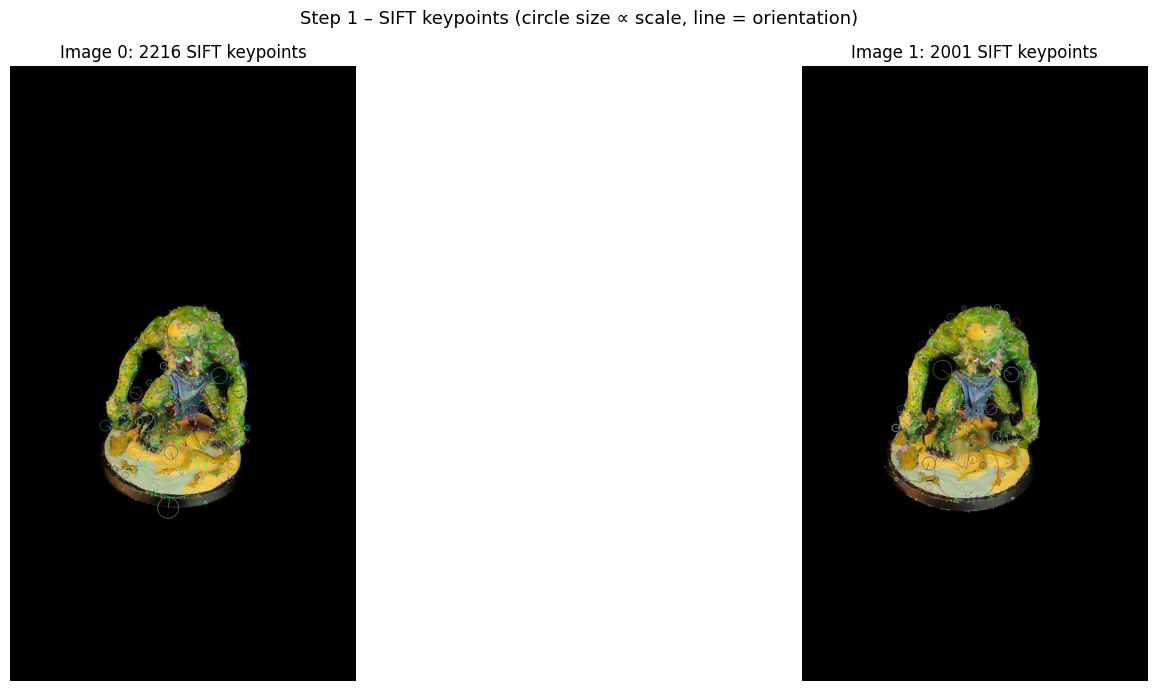

In [37]:
sift = cv2.SIFT_create()

keypoints_list = []
descriptors_list = []

for img in images:
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
    kps, descs = sift.detectAndCompute(gray, None)
    keypoints_list.append(kps)
    descriptors_list.append(descs)

print(f"Keypoints per image: {[len(kps) for kps in keypoints_list]}")

# Visualise keypoints on the first two images
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for i, ax in enumerate(axes):
    vis = cv2.drawKeypoints(
        np.array(images[i]),
        keypoints_list[i],
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
    )
    ax.imshow(vis)
    ax.set_title(f"Image {i}: {len(keypoints_list[i])} SIFT keypoints")
    ax.axis("off")
plt.suptitle("Step 1 – SIFT keypoints (circle size ∝ scale, line = orientation)", fontsize=13)
plt.tight_layout()
plt.show()

## Feature Matching, RANSAC, and 3-D Back-Projection

In [42]:
SRC, TGT = 1, 2   # change these to test different frame pairs

# Lowe ratio test
bf = cv2.BFMatcher()
raw = bf.knnMatch(descriptors_list[SRC], descriptors_list[TGT], k=2)
good = [m for m, n in raw if m.distance < 0.75 * n.distance]
print(f"After ratio test : {len(good)} matches")

After ratio test : 56 matches


After RANSAC     : 11 inliers


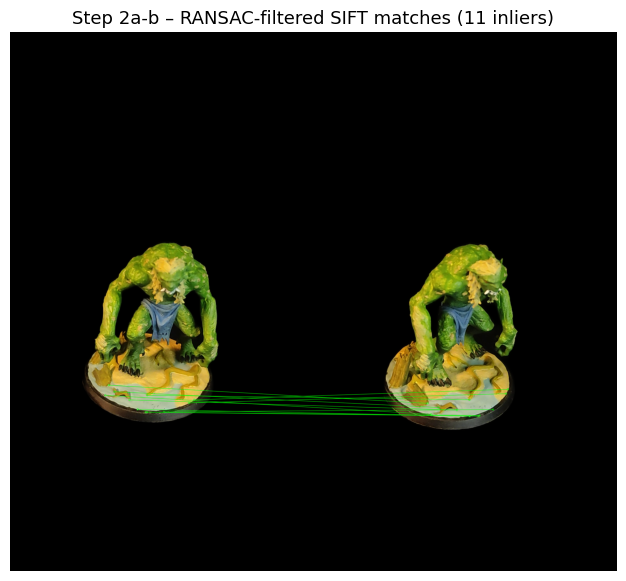

In [43]:
# RANSAC homography – 2-D geometric outlier rejection
src_pts_2d = np.float32([keypoints_list[SRC][m.queryIdx].pt for m in good])
tgt_pts_2d = np.float32([keypoints_list[TGT][m.trainIdx].pt for m in good])

_, mask = cv2.findHomography(src_pts_2d, tgt_pts_2d, cv2.RANSAC)
keep = mask.ravel().astype(bool)
inlier_matches = [m for m, k in zip(good, keep) if k]
src_pts_2d, tgt_pts_2d = src_pts_2d[keep], tgt_pts_2d[keep]
print(f"After RANSAC     : {len(inlier_matches)} inliers")

# Visualise 2-D matches
match_img = cv2.drawMatches(
    np.array(images[SRC]), keypoints_list[SRC],
    np.array(images[TGT]), keypoints_list[TGT],
    inlier_matches, None,
    matchColor=(0, 255, 0),
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)
plt.figure(figsize=(22, 7))
plt.imshow(match_img)
plt.title(f"Step 2a-b – RANSAC-filtered SIFT matches ({len(inlier_matches)} inliers)", fontsize=13)
plt.axis("off")
plt.show()

3-D feature pairs with valid depth: 11


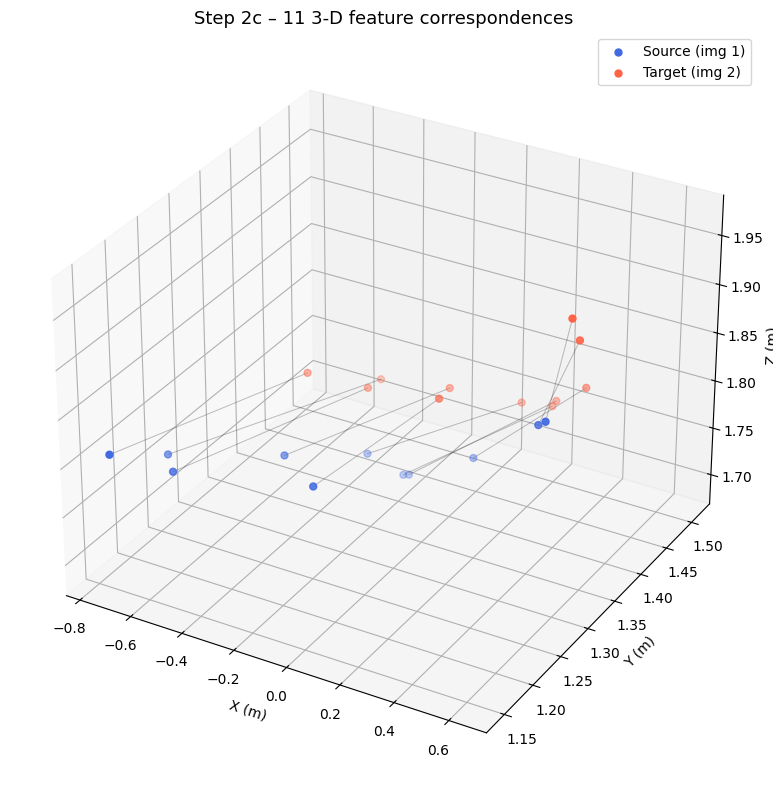

In [44]:
# Back-project to 3-D using pinhole model
def backproject(pts_2d, depth_map, fx, fy, cx, cy):
    """
    For each 2-D pixel (u, v) sample the depth map to get Z, then:
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy
    Invalid points (zero depth / out-of-bounds) → NaN row.
    """
    out = np.full((len(pts_2d), 3), np.nan, dtype=np.float64)
    h, w = depth_map.shape[:2]
    for i, (u, v) in enumerate(pts_2d):
        ui, vi = int(round(u)), int(round(v))
        if 0 <= vi < h and 0 <= ui < w:
            Z = float(depth_map[vi, ui])
            if Z > 0:
                out[i] = [(u - cx) * Z / fx, (v - cy) * Z / fy, Z]
    return out

src_3d_all = backproject(src_pts_2d, depth_maps[SRC], fx, fy, cx, cy)
tgt_3d_all = backproject(tgt_pts_2d, depth_maps[TGT], fx, fy, cx, cy)

valid = ~np.isnan(src_3d_all).any(axis=1) & ~np.isnan(tgt_3d_all).any(axis=1)
src_3d = src_3d_all[valid]
tgt_3d = tgt_3d_all[valid]
print(f"3-D feature pairs with valid depth: {valid.sum()}")

# Visualise 3-D correspondences
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*src_3d.T, c="royalblue", s=25, label=f"Source (img {SRC})", depthshade=True)
ax.scatter(*tgt_3d.T, c="tomato",    s=25, label=f"Target (img {TGT})", depthshade=True)

step = max(1, len(src_3d) // 40)          # subsample to avoid clutter
for s, t in zip(src_3d[::step], tgt_3d[::step]):
    ax.plot([s[0], t[0]], [s[1], t[1]], [s[2], t[2]], "k-", alpha=0.25, linewidth=0.7)

ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
ax.legend()
ax.set_title(f"Step 2c – {valid.sum()} 3-D feature correspondences", fontsize=13)
plt.tight_layout()
plt.show()